In [2]:
import pandas as pd

pd.setoption('display.maxcolwidth', None)
pd.setoption('display.width', 2000)
pd.setoption('display.expandframerepr', False)  # Disable line-wrapping
pd.setoption('display.max rows', None)

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

coffee_data = pd.read_csv(r"..\data\reduced_data_bin.csv")
df = pd.read_csv(r"..\data\reduced_data.csv")

df = pd.concat([df, coffee_data["caffeine_percent"]], axis=1)

df = df.fillna(0)

#print(df)


In [130]:
num_zeros = (df['env_76_soi'] == 0).sum()
print(f"Number of 0s in column 'env_76_soi': {num_zeros}")
#print(df[['env_76_soi', 'caffeine_percent']])
num_nans = df['env_76_soi'].isna().sum()
print(f"Number of NaNs in column 'env_76_soi': {num_nans}")

item_counts = df['env_76_soi'].value_counts()
#print(item_counts)
counts_df = item_counts.reset_index()
counts_df.columns = ['Item', 'Count']
# Convert the 'Item' column to strings for mapping
counts_df['Item'] = counts_df['Item'].astype(int).astype(str)

# Convert mapping_dict keys to strings (if not already done)
mapping_dict = {str(key): value for key, value in mapping_dict.items()}

# Apply the mapping
counts_df['mapped_column'] = counts_df['Item'].map(mapping_dict)

# Print the updated DataFrame
print(counts_df[['mapped_column', 'Count']])


Number of 0s in column 'env_76_soi': 46
Number of NaNs in column 'env_76_soi': 0
                                                             mapped_column  Count
0                                                       Hydromorphic Soils     73
1                                               Podzolic Soils and Podzols     58
2                                                   Humic Ferralitic Soils     56
3                                                                 Andosols     48
4                                                                  No Data     46
5                                                    Salty Deposited Soils     46
6             Rejuvenated Ferralitic Soils with Little Degrading Structure     37
7                                Skeletal Shallow Eroded Ferruginous Soils     28
8                                       Humic Rejuvenated Ferralitic Soils     26
9                                                                Vertisols     25
10               

Soil type distribution

In [102]:
# Create a sub DataFrame with the selected columns
soi_df = df[['env_76_soi', 'caffeine_percent']]

# Drop rows with NaN values
#soi_df = soi_df.dropna()
category_means = soi_df.groupby('env_76_soi')['caffeine_percent'].mean()
sorted_categories = category_means.sort_values(ascending=False).index
soi_df['env_76_soi'] = pd.Categorical(soi_df['env_76_soi'], categories=sorted_categories, ordered=True)


In [165]:
mapping_dict = {
    '5': 'Alluvio-colluvial Deposited Soils',
    '9': 'Andosols',
    '1': 'Bare Rocks',
    '7': 'Fluvio-marine Deposited Soils - Mangroves',
    '23': 'Highly Rejuvenated, Penevoluted Ferralitic Soils',
    '18': 'Humic Ferralitic Soils',
    '20': 'Humic Rejuvenated Ferralitic Soils',
    '11': 'Hydromorphic Soils',
    '19': 'Indurated-Concretion Ferralitic Soils',
    '10': 'Podzolic Soils and Podzols',
    '3': 'Poorly Evolved Erosion Soils, Lithosols',
    '2': 'Raw Lithic Mineral Soils',
    '15': 'Red Ferruginous Soils',
    '12': 'Red Fersiallitic Soils',
    '22': 'Rejuvenated Ferralitic Soils with Degrading Structure',
    '21': 'Rejuvenated Ferralitic Soils with Little Degrading Structure',
    '6': 'Salty Deposited Soils',
    '16': 'Skeletal Shallow Eroded Ferruginous Soils',
    '17': 'Typical Reddish-brown Ferralitic Soils with Little Degrading Structure',
    '8': 'Vertisols',
    '4': 'Wind-deposited Soils',
    '14': 'Yellow-red Ferruginous Soils (Red Sands)',
    '13': 'Yellow Fersiallitic Soils',
    '0': 'No Data'
}


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


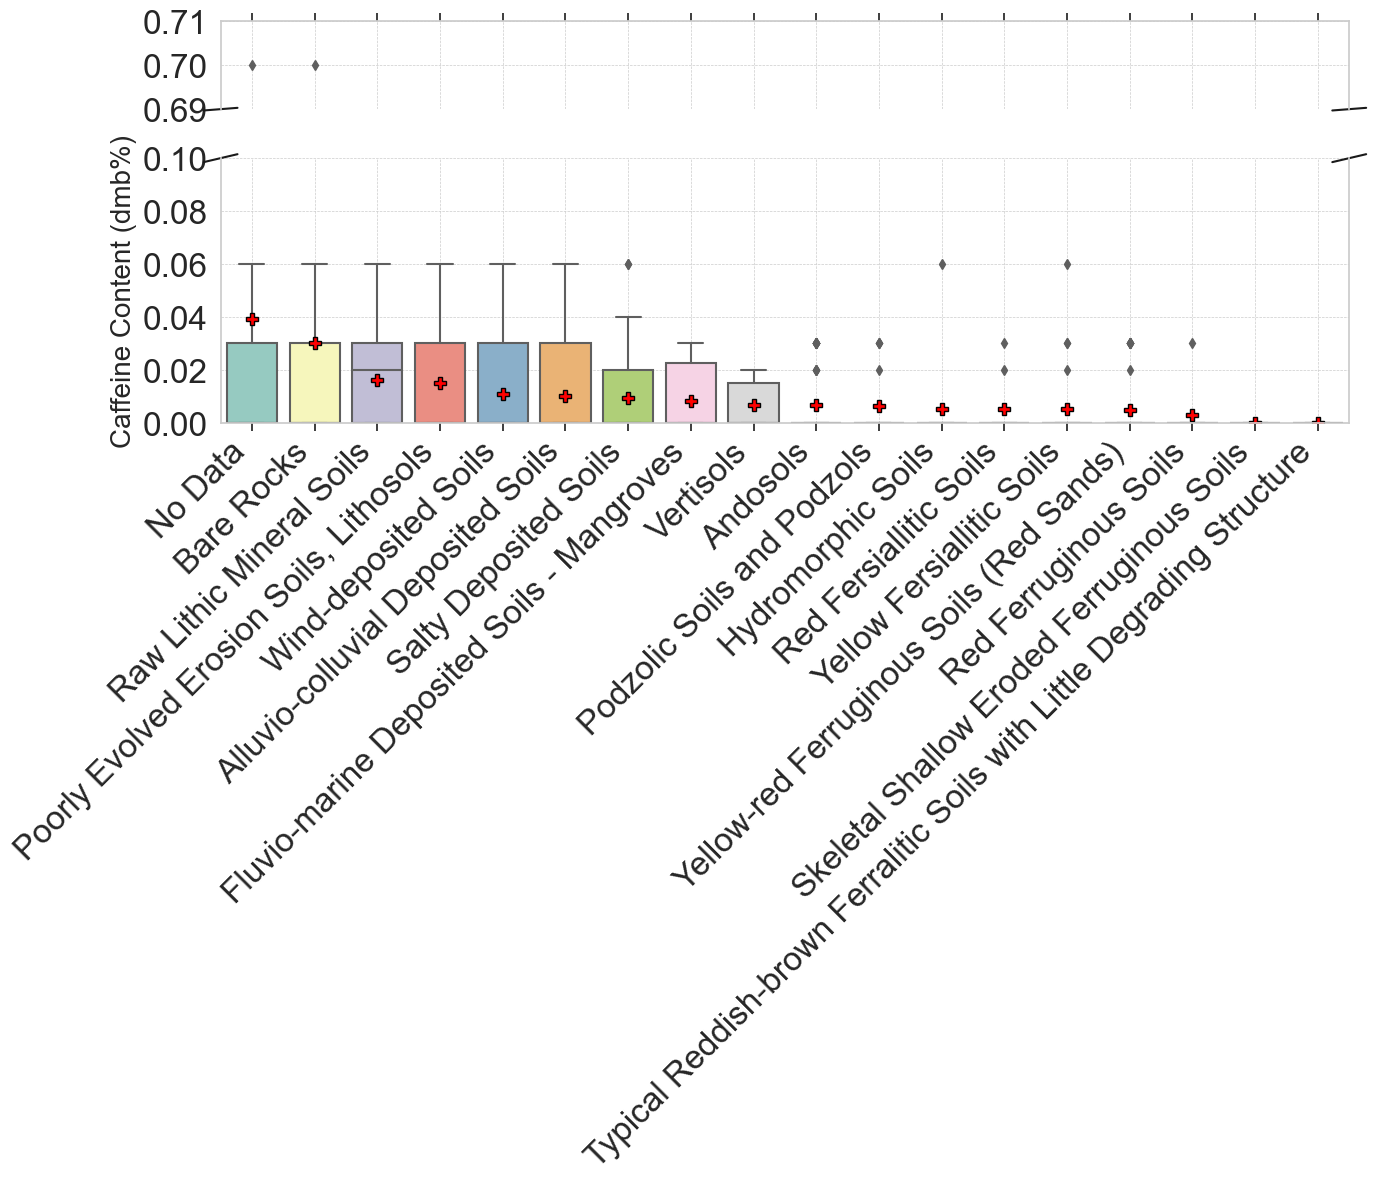

In [166]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

meanprops = {
    'marker': 'P',  # Change the marker to 'o' (circle), 's' (square), etc.
    'markerfacecolor': 'red',  # Change the fill color of the marker
    'markeredgecolor': 'black',  # Change the edge color of the marker
    'markersize': 8  # Change the size of the marker
}

# Set the plot style
sns.set(style="whitegrid")

# Create a figure with subplots for the box plot and violin plot (2 subplots per plot)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 12),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_76_soi', y='caffeine_percent', data=soi_df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_76_soi', y='caffeine_percent', data=soi_df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part

ax1.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the top plot
ax2.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the bottom plot

# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')
ax2.set_ylabel('Caffeine Content (dmb%)', fontsize=20)
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

current_labels = plt.gca().get_xticks()
new_labels = [mapping_dict.get(str(int(label)), label) for label in current_labels]  # Convert labels to int and then to str for matching

plt.gca().set_xticklabels(new_labels, rotation=45, ha='right')  # Rotate labels 45 degrees and align to the right


plt.tight_layout()
plt.show()

Rock types

In [168]:
mapping_dict = {
    '1': 'Alluvial & Lake deposits',
    '10': 'Basement Rocks (Igneous & Metamorphic)',
    '9': 'Lavas (including Basalts & Gabbros)',
    '4': 'Mangrove Swamp',
    '13': 'Marble (Cipolin)',
    '7': 'Mesozoic Limestones + Marls (incl. "Tsingy")',
    '12': 'Quartzites',
    '3': 'Other',
    '6': 'Sandstones',
    '5': 'Tertiary Limestones + Marls & Chalks',
    '11': 'Ultrabasics',
    '2': 'Unconsolidated Sands',
    '0': 'No Data'
}


In [144]:
# Create a sub DataFrame with the selected columns
geo_df = df[['env_75_geo', 'caffeine_percent']].copy()

category_means = geo_df.groupby('env_75_geo')['caffeine_percent'].mean()
sorted_categories = category_means.sort_values(ascending=False).index
geo_df['env_75_geo'] = pd.Categorical(geo_df['env_75_geo'], categories=sorted_categories, ordered=True)

item_counts = df['env_75_geo'].value_counts()
#print(item_counts)
counts_df = item_counts.reset_index()
counts_df.columns = ['Item', 'Count']
# Convert the 'Item' column to strings for mapping
counts_df['Item'] = counts_df['Item'].astype(int).astype(str)

# Convert mapping_dict keys to strings (if not already done)
mapping_dict = {str(key): value for key, value in mapping_dict.items()}
#mapping_dict = {k: v for k, v in mapping_dict.items() if float(k) in valid_categories}

# Apply the mapping
counts_df['mapped_column'] = counts_df['Item'].map(mapping_dict)

# Print the updated DataFrame
print(counts_df[['mapped_column', 'Count', "Item"]])



c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


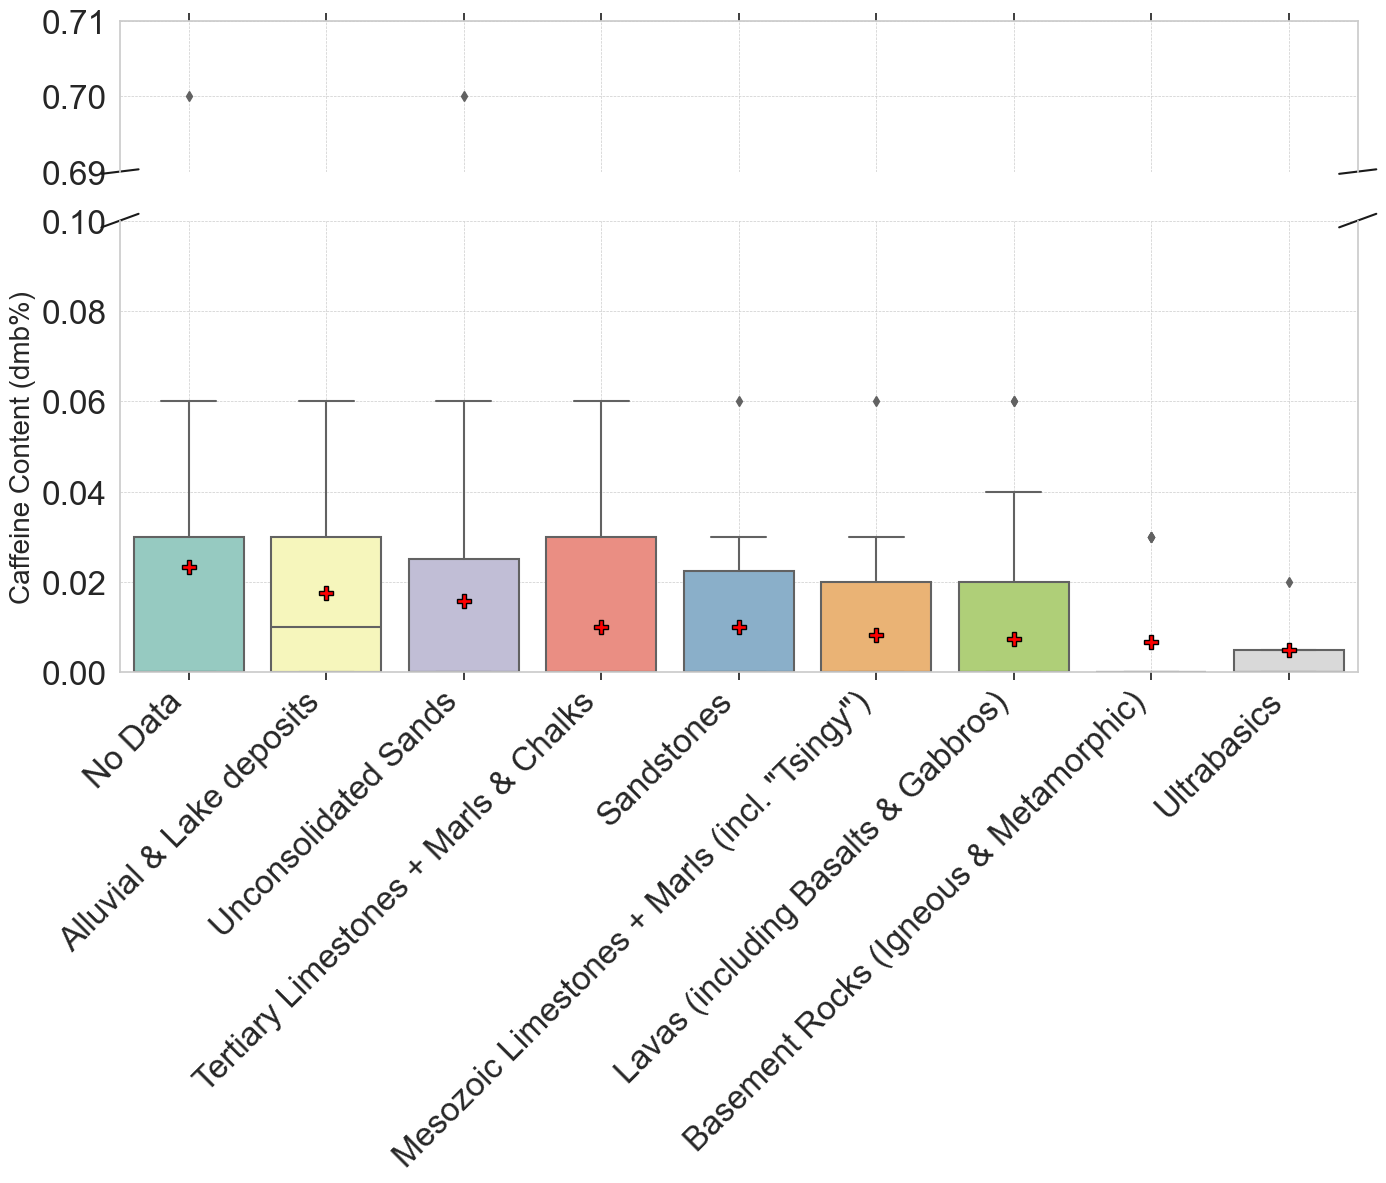

In [170]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

meanprops = {
    'marker': 'P',  # Change the marker to 'o' (circle), 's' (square), etc.
    'markerfacecolor': 'red',  # Change the fill color of the marker
    'markeredgecolor': 'black',  # Change the edge color of the marker
    'markersize': 10  # Change the size of the marker
}

# Set the plot style
sns.set(style="whitegrid")

# Create a figure with subplots for the box plot and violin plot (2 subplots per plot)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 12),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_75_geo', y='caffeine_percent', data=geo_df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_75_geo', y='caffeine_percent', data=geo_df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part
ax1.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the top plot
ax2.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the bottom plot
# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')
ax2.set_ylabel('Caffeine Content (dmb%)', fontsize=20)
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

current_labels = plt.gca().get_xticks()

valid_categories = sorted(geo_df['env_75_geo'].unique())

# Map the valid categories to their names using mapping_dict
new_labels = [mapping_dict.get(str(int(cat)), f"Unknown ({cat})") for cat in valid_categories]

#new_labels = [mapping_dict.get(str(int(label)), label) for label in current_labels]  # Convert labels to int and then to str for matching

plt.gca().set_xticklabels(new_labels, rotation=45, ha='right')  # Rotate labels 45 degrees and align to the right


plt.tight_layout()
plt.show()

Watersheds

In [172]:
mapping_dict = {
    '9': 'CoE E-Betsiboka S-Maevarano',
    '1': 'CoE N-Bemarivo',
    '10': 'CoE N-Maevarano S-Sambirano',
    '12': 'CoE N-Mahavavy',
    '7': 'CoE N-Mangoky S-Tsiribihina',
    '11': 'CoE N-Sambirano W-Mahavavy',
    '8': 'CoE N-Tsiribihina W-Betsiboka',
    '2': 'CoE S-Bemarivo N-Mangoro',
    '6': 'Other',
    '4': 'CoE S-Manampatrana N-Mananara',
    '5': 'CoE S-Mananara',
    '20': 'CoE S-Mangoky',
    '3': 'CoE S-Mangoro N-Manampatrana',
    '14': 'RetDisp Antainambalana',
    '13': 'RetDisp Bemarivo',
    '22': 'RetDisp Betsiboka',
    '23': 'RetDisp Maevarana (1/2 N)',
    '25': 'RetDisp Mahavavy',
    '16': 'RetDisp Manampatrana',
    '17': 'RetDisp Mananara du Sud',
    '1': 'RetDisp Mandrare',
    '18': 'RetDisp Mangoky',
    '15': 'RetDisp Mangoro',
    '19': 'RetDisp Onilahy',
    '24': 'RetDisp Sambirano',
    '21': 'RetDisp Tsiribihina',
    '0': 'No Data'
}


In [149]:
wat_df = df[['env_78_wat', 'caffeine_percent']].copy()

category_means = wat_df.groupby('env_78_wat')['caffeine_percent'].mean()
sorted_categories = category_means.sort_values(ascending=False).index
wat_df['env_78_wat'] = pd.Categorical(wat_df['env_78_wat'], categories=sorted_categories, ordered=True)

item_counts = df['env_78_wat'].value_counts()
print(item_counts)
counts_df = item_counts.reset_index()
counts_df.columns = ['Item', 'Count']
# Convert the 'Item' column to strings for mapping
counts_df['Item'] = counts_df['Item'].astype(int).astype(str)

# Convert mapping_dict keys to strings (if not already done)
mapping_dict = {str(key): value for key, value in mapping_dict.items()}
#mapping_dict = {k: v for k, v in mapping_dict.items() if float(k) in valid_categories}

# Apply the mapping
counts_df['mapped_column'] = counts_df['Item'].map(mapping_dict)

# Print the updated DataFrame
print(counts_df[['mapped_column', 'Count', "Item"]])


env_78_wat
2.0     110
1.0      81
3.0      64
8.0      59
6.0      58
0.0      46
12.0     29
4.0      25
14.0     15
5.0      13
10.0      8
13.0      5
11.0      3
22.0      2
18.0      2
17.0      2
20.0      2
9.0       1
15.0      1
Name: count, dtype: int64
                    mapped_column  Count Item
0        CoE S-Bemarivo N-Mangoro    110    2
1                RetDisp Mandrare     81    1
2    CoE S-Mangoro N-Manampatrana     64    3
3   CoE N-Tsiribihina W-Betsiboka     59    8
4                           Other     58    6
5                         No Data     46    0
6                  CoE N-Mahavavy     29   12
7   CoE S-Manampatrana N-Mananara     25    4
8          RetDisp Antainambalana     15   14
9                  CoE S-Mananara     13    5
10    CoE N-Maevarano S-Sambirano      8   10
11               RetDisp Bemarivo      5   13
12     CoE N-Sambirano W-Mahavavy      3   11
13              RetDisp Betsiboka      2   22
14                RetDisp Mangoky      2   18

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


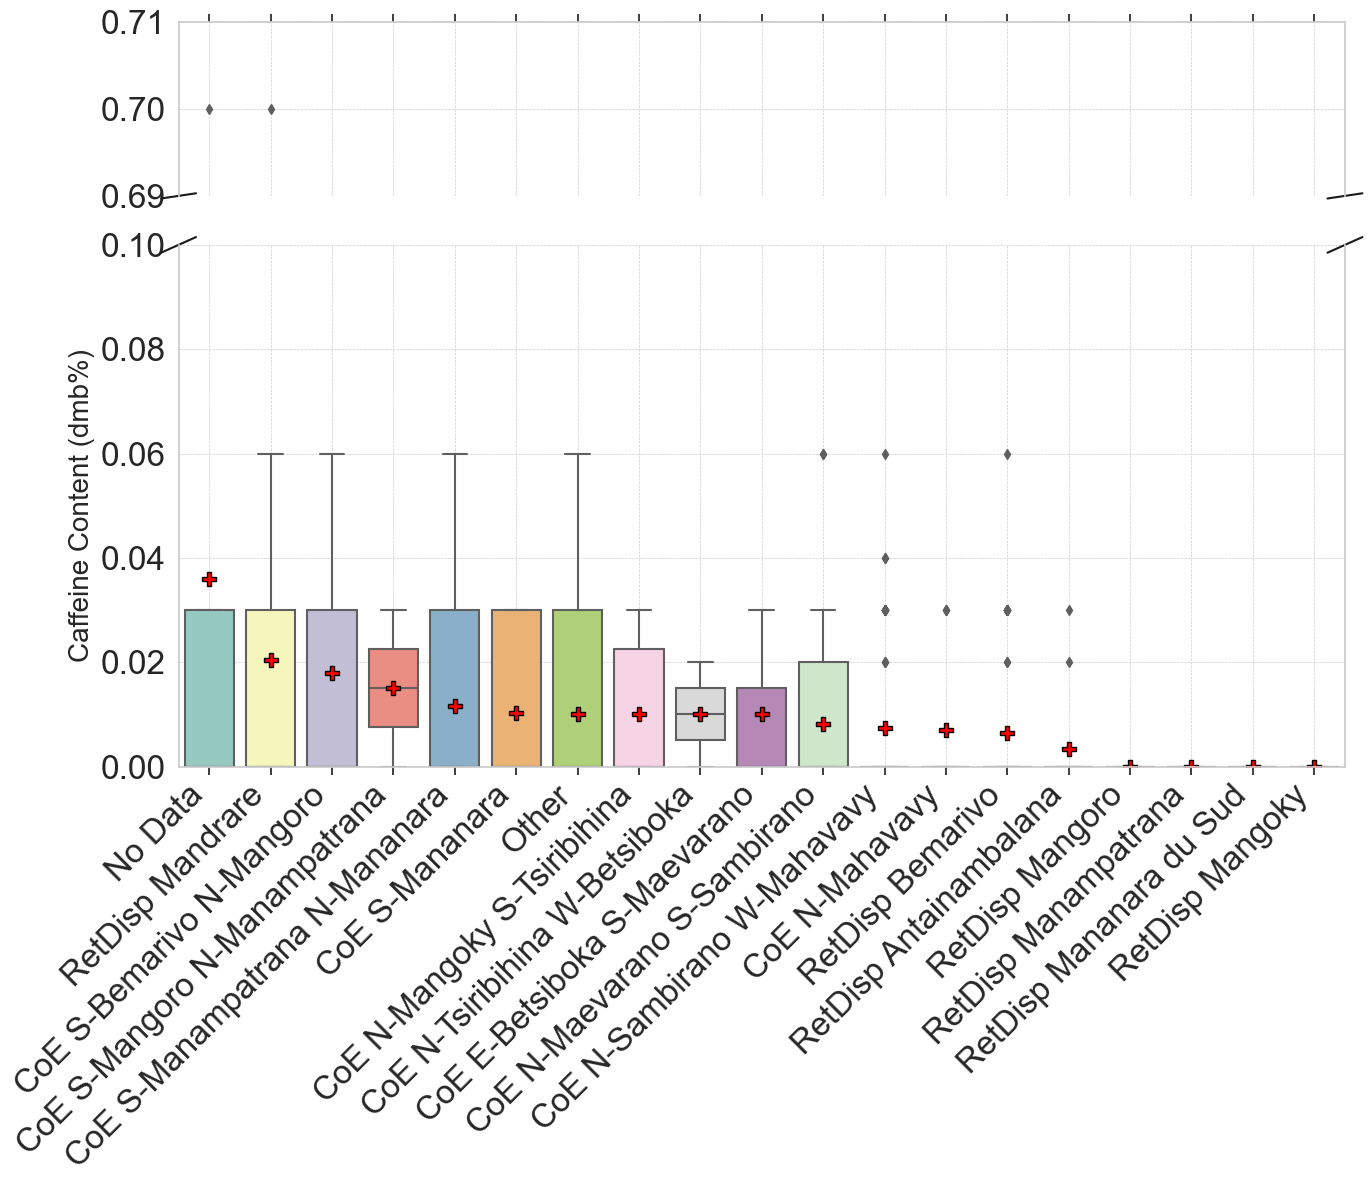

In [173]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

meanprops = {
    'marker': 'P',  # Change the marker to 'o' (circle), 's' (square), etc.
    'markerfacecolor': 'red',  # Change the fill color of the marker
    'markeredgecolor': 'black',  # Change the edge color of the marker
    'markersize': 10  # Change the size of the marker
}

# Set the plot style
sns.set(style="whitegrid")

# Create a figure with subplots for the box plot and violin plot (2 subplots per plot)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 12),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_78_wat', y='caffeine_percent', data=wat_df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_78_wat', y='caffeine_percent', data=wat_df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part
ax1.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the top plot
ax2.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the bottom plot
# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')
ax2.set_ylabel('Caffeine Content (dmb%)', fontsize=20)
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

current_labels = plt.gca().get_xticks()
new_labels = [mapping_dict.get(str(int(label)), label) for label in current_labels]  # Convert labels to int and then to str for matching

plt.gca().set_xticklabels(new_labels, rotation=45, ha='right')  # Rotate labels 45 degrees and align to the right


plt.tight_layout()
plt.show()

Vegetation

In [175]:
mapping_dict = {
    '1': 'South western coastal bushland',
    '2': 'Degraded south western dry spiny forest',
    '3': 'Tapia forest',
    '4': 'Cultivation',
    '5': 'Western dry forest',
    '6': 'Plateau grassland-wooded grassland mosaic',
    '7': 'Wooded grassland-bushland mosaic',
    '8': 'Other',
    '9': 'Other',
    '10': 'Bare Soil/rock',
    '11': 'Wetlands',
    '12': 'South western dry spiny forest-thicket',
    '13': 'Western sub-humid forest',
    '14': 'Humid Forest',
    '15': 'Other',
    '16': 'Degraded Humid Forest',
    '19': 'Littoral forest',
    '22': 'Mangroves',
    '23': 'Western humid forest',
    '25': 'Sea/Water',
    '0': 'No Data'
}


In [155]:
veg_df = df[['env_77_veg', 'caffeine_percent']].copy()

category_means = veg_df.groupby('env_77_veg')['caffeine_percent'].mean()
sorted_categories = category_means.sort_values(ascending=False).index
veg_df['env_77_veg'] = pd.Categorical(veg_df['env_77_veg'], categories=sorted_categories, ordered=True)

item_counts = df['env_77_veg'].value_counts()
print(item_counts)
counts_df = item_counts.reset_index()
counts_df.columns = ['Item', 'Count']
# Convert the 'Item' column to strings for mapping
counts_df['Item'] = counts_df['Item'].astype(int).astype(str)

# Convert mapping_dict keys to strings (if not already done)
mapping_dict = {str(key): value for key, value in mapping_dict.items()}
#mapping_dict = {k: v for k, v in mapping_dict.items() if float(k) in valid_categories}

# Apply the mapping
counts_df['mapped_column'] = counts_df['Item'].map(mapping_dict)

# Print the updated DataFrame
print(counts_df[['mapped_column', 'Count', "Item"]])

env_77_veg
16.0    135
14.0     96
5.0      63
6.0      58
7.0      57
0.0      46
15.0     20
12.0     15
4.0      15
22.0     11
9.0       4
1.0       2
13.0      1
2.0       1
3.0       1
11.0      1
Name: count, dtype: int64
                                mapped_column  Count Item
0                       Degraded Humid Forest    135   16
1                                Humid Forest     96   14
2                          Western dry forest     63    5
3   Plateau grassland-wooded grassland mosaic     58    6
4            Wooded grassland-bushland mosaic     57    7
5                                       Other     46    0
6                                       Other     20   15
7      South western dry spiny forest-thicket     15   12
8                                 Cultivation     15    4
9                                   Mangroves     11   22
10                                      Other      4    9
11             South western coastal bushland      2    1
12               

In [157]:
veg_df['env_77_veg'] = veg_df['env_77_veg'].replace({9: 8, 15: 8})
print(veg_df['env_77_veg'].unique())


[12.0, 14.0, 7.0, 8.0, 16.0, ..., 13.0, 2.0, 3.0, 11.0, 0.0]
Length: 15
Categories (15, float64): [5.0 < 7.0 < 0.0 < 12.0 ... 2.0 < 1.0 < 13.0 < 11.0]


C:\Users\adm1\AppData\Local\Temp\ipykernel_82104\558788683.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  veg_df['env_77_veg'] = veg_df['env_77_veg'].replace({9: 8, 15: 8})


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


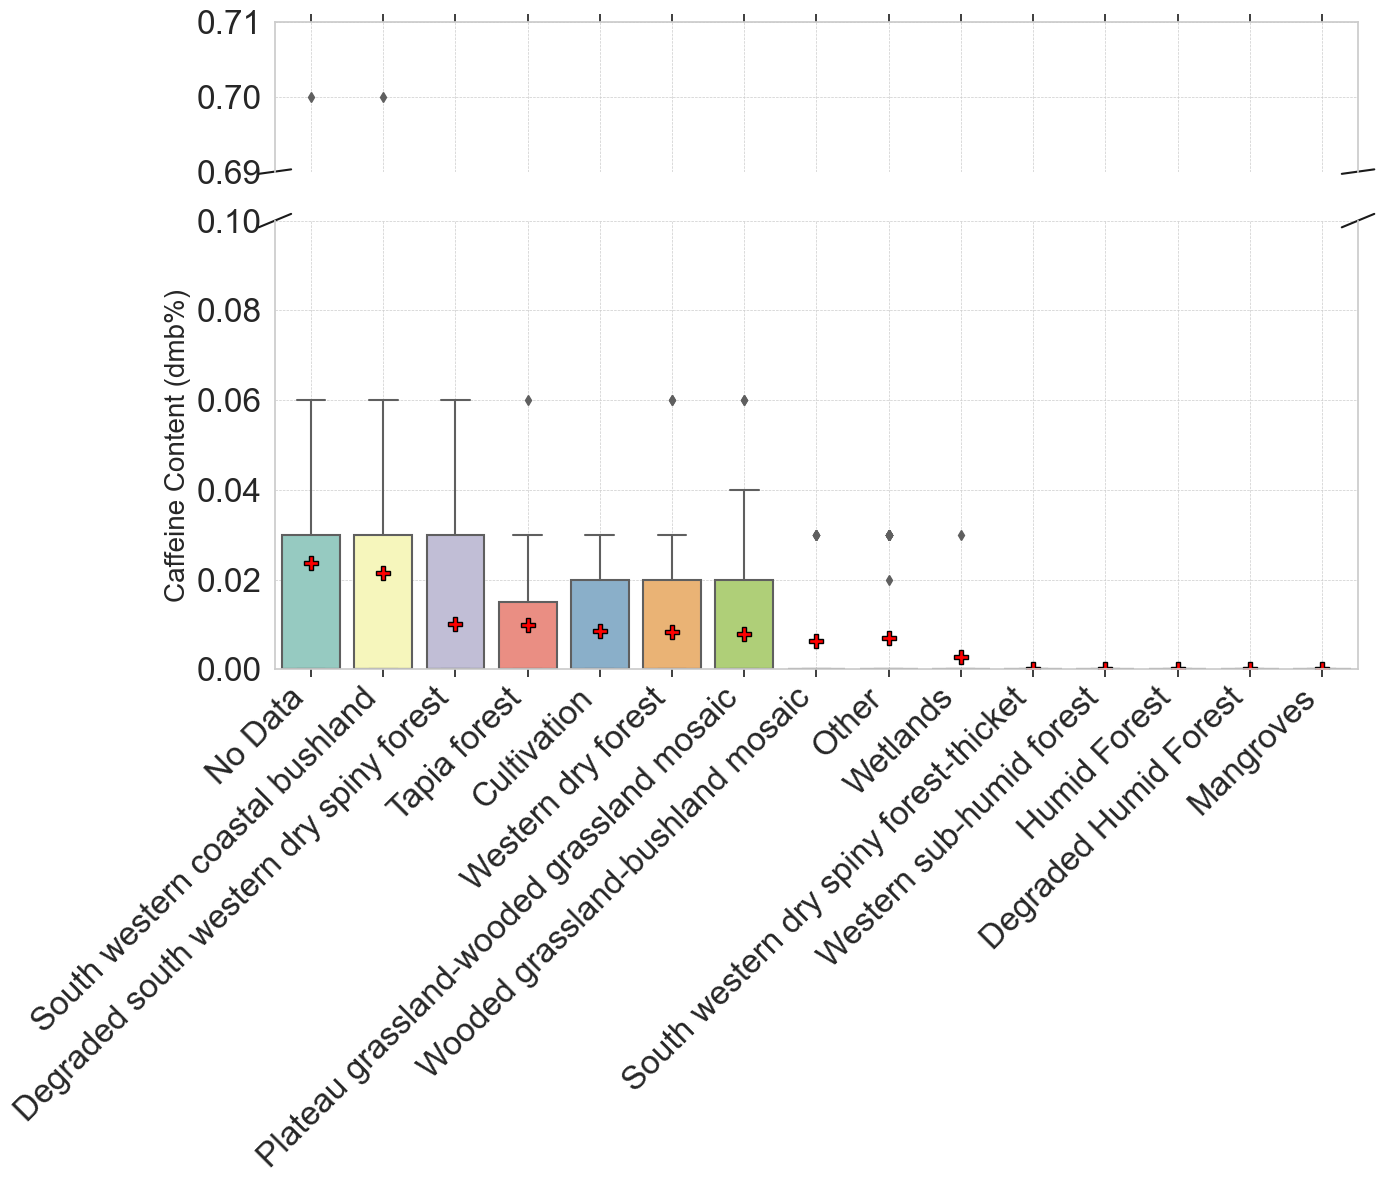

In [176]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

meanprops = {
    'marker': 'P',  # Change the marker to 'o' (circle), 's' (square), etc.
    'markerfacecolor': 'red',  # Change the fill color of the marker
    'markeredgecolor': 'black',  # Change the edge color of the marker
    'markersize': 10  # Change the size of the marker
}

# Set the plot style
sns.set(style="whitegrid")

# Create a figure with subplots for the box plot and violin plot (2 subplots per plot)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 12),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_77_veg', y='caffeine_percent', data=veg_df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_77_veg', y='caffeine_percent', data=veg_df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part
ax1.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the top plot
ax2.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the bottom plot
# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')
ax2.set_ylabel('Caffeine Content (dmb%)', fontsize=20)
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

current_labels = plt.gca().get_xticks()
valid_categories = sorted(veg_df['env_77_veg'].unique())

# Map the valid categories to their names using mapping_dict
new_labels = [mapping_dict.get(str(int(cat)), f"Unknown ({cat})") for cat in valid_categories]
#new_labels = [mapping_dict.get(str(int(label)), label) for label in current_labels]  # Convert labels to int and then to str for matching

plt.gca().set_xticklabels(new_labels, rotation=45, ha='right')  # Rotate labels 45 degrees and align to the right


plt.tight_layout()
plt.show()

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


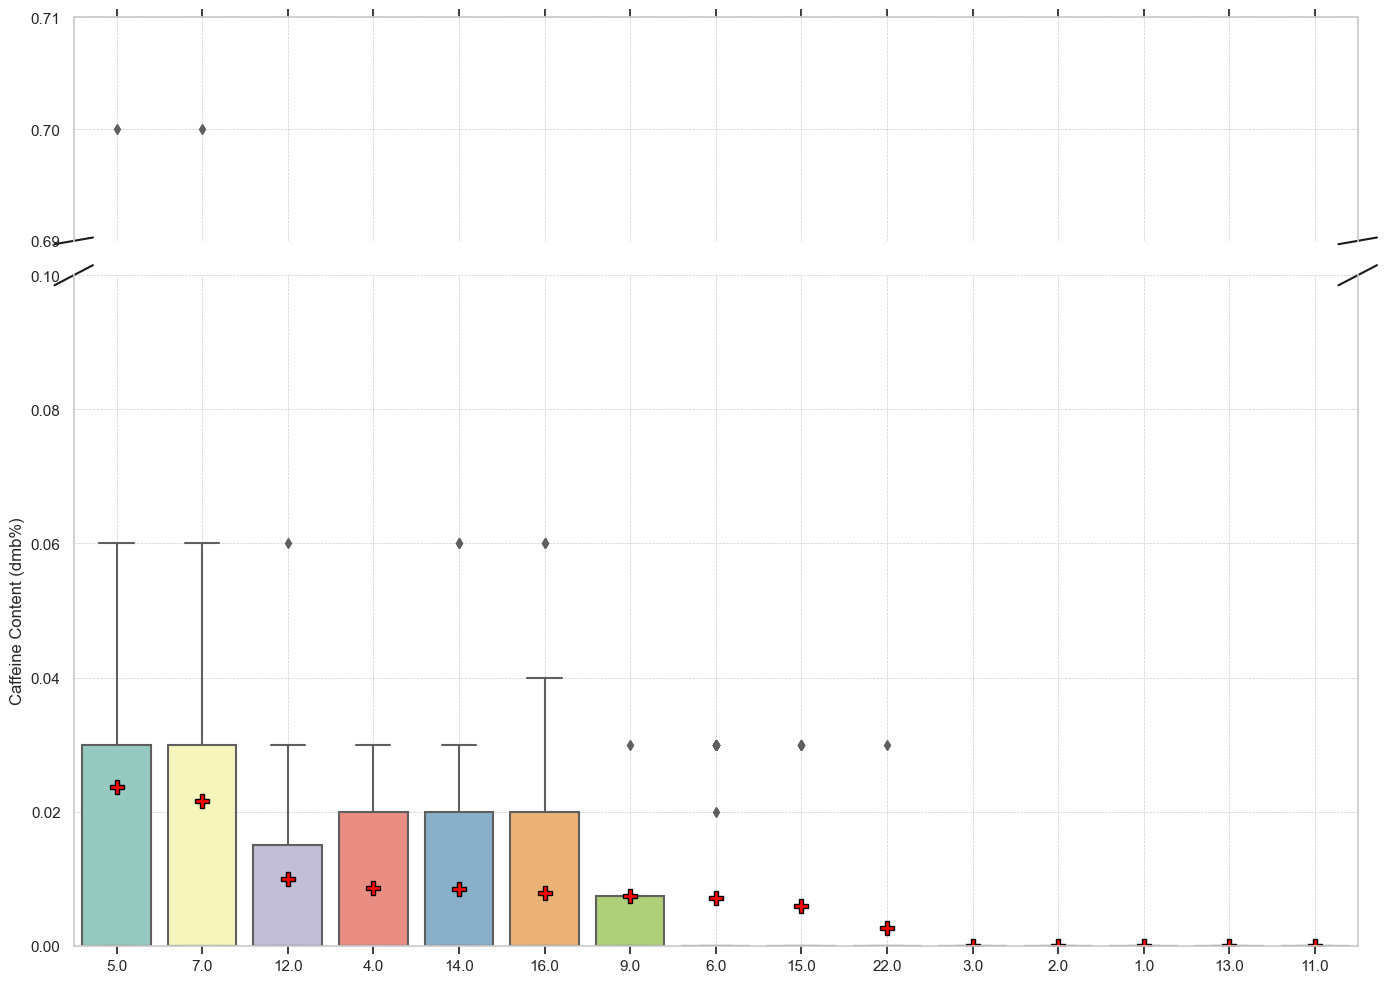

In [50]:
# Calculate the mean caffeine content for each category in 'env_77_veg'
category_means = df.groupby('env_77_veg')['caffeine_percent'].mean()

# Sort the categories by mean caffeine content in descending order
sorted_categories = category_means.sort_values(ascending=False).index

# Create a new column with the sorted categories
df['env_77_veg_sorted'] = pd.Categorical(df['env_77_veg'], categories=sorted_categories, ordered=True)

# Use the sorted column for plotting
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_77_veg_sorted', y='caffeine_percent', data=df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_77_veg_sorted', y='caffeine_percent', data=df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part

# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')
ax2.set_ylabel('Caffeine Content (dmb%)')
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


ValueError: min() iterable argument is empty

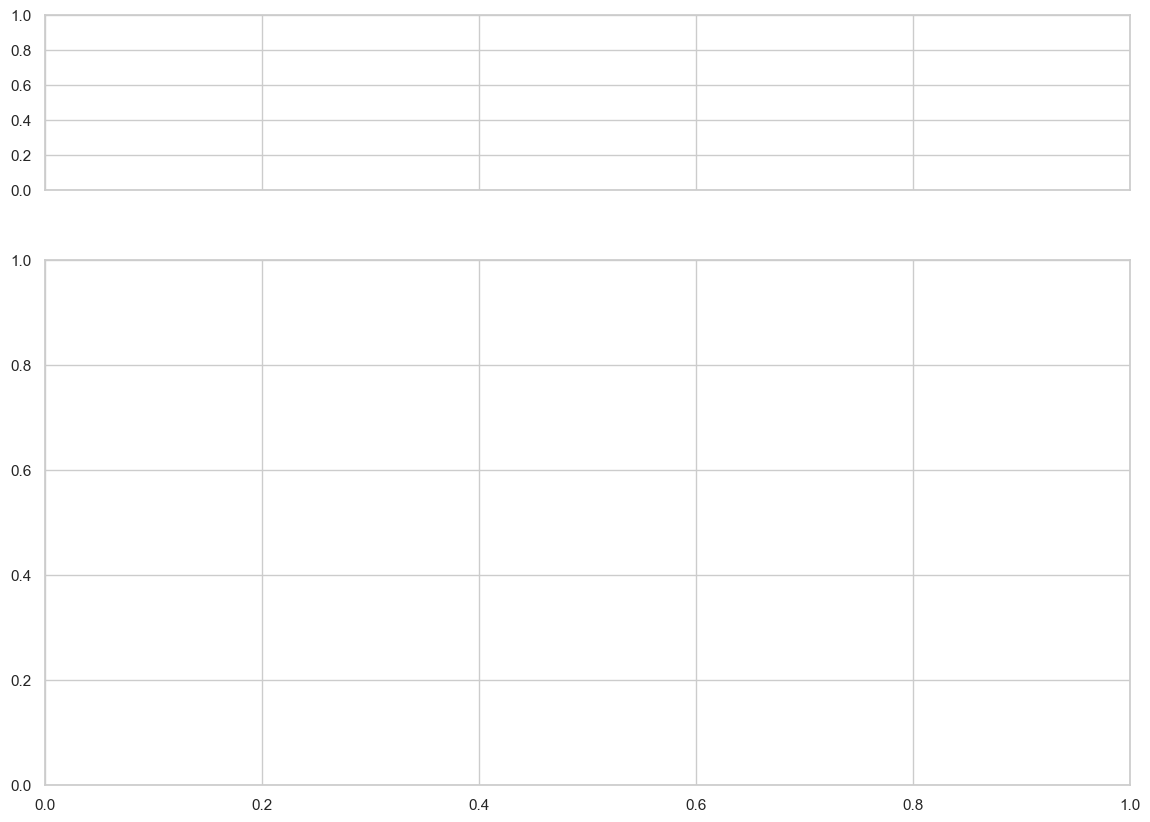

In [72]:
# Drop rows with NaNs in 'env_77_veg' or 'caffeine_percent'
df = df.dropna(subset=['env_77_veg', 'caffeine_percent'])

# Remove rows where 'env_77_veg' is not in the mapping dictionary
df = df[df['env_77_veg'].isin(mapping_dict.keys())]

# Calculate the mean caffeine content for each category in 'env_77_veg'
category_means = df.groupby('env_77_veg')['caffeine_percent'].mean()

# Sort the categories by mean caffeine content in descending order
sorted_categories = category_means.sort_values(ascending=False).index

# Create a new column with the sorted categories
df['env_77_veg_sorted'] = pd.Categorical(df['env_77_veg'], categories=sorted_categories, ordered=True)

# Map the categories to their descriptive labels
df['env_77_veg_mapped'] = df['env_77_veg'].map(mapping_dict)

# Ensure 'env_77_veg_mapped' is also sorted by the mean caffeine content
df['env_77_veg_mapped'] = pd.Categorical(df['env_77_veg_mapped'], categories=[mapping_dict[str(cat)] for cat in sorted_categories], ordered=True)

# Plot
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_77_veg_mapped', y='caffeine_percent', data=df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_77_veg_mapped', y='caffeine_percent', data=df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part

# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')  # Remove default x-axis label
ax2.set_ylabel('Caffeine Content (dmb%)')
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=12)

plt.tight_layout()
plt.show()


In [54]:
print(df[['env_77_veg_mapped', 'caffeine_percent']].head())
print(df[['env_77_veg_mapped', 'caffeine_percent']].isnull().sum())


   env_77_veg_mapped  caffeine_percent
0                NaN              0.00
1                NaN              0.03
2                NaN              0.00
3                NaN              0.00
4                NaN              0.00
env_77_veg_mapped    526
caffeine_percent       0
dtype: int64


In [55]:
unmapped_values = set(df['env_77_veg'].unique()) - set(mapping_dict.keys())
print("Unmapped values:", unmapped_values)


Unmapped values: {1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, nan, 9.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 22.0}


In [56]:
print(df['env_77_veg'].value_counts())
print(df['env_77_veg_mapped'].value_counts())


env_77_veg
16.0    135
14.0     96
5.0      63
6.0      58
7.0      57
15.0     20
12.0     15
4.0      15
22.0     11
9.0       4
1.0       2
3.0       1
2.0       1
13.0      1
11.0      1
Name: count, dtype: int64
Series([], Name: count, dtype: int64)


In [58]:
print("Mapped categories:", df['env_77_veg_mapped'].unique())
print("Caffeine data present:", not df['caffeine_percent'].empty)


Mapped categories: [nan]
Caffeine data present: True


In [59]:
# Ensure 'env_77_veg' is a Categorical with sorted categories
df['env_77_veg'] = pd.Categorical(df['env_77_veg'], categories=sorted_categories, ordered=True)

# Add "Unknown" as a valid category to avoid errors
df['env_77_veg'] = df['env_77_veg'].cat.add_categories(['Unknown'])

# Fill missing values in 'env_77_veg' with "Unknown"
df['env_77_veg'] = df['env_77_veg'].fillna('Unknown')

# Map to descriptive labels and handle unmapped values
df['env_77_veg_mapped'] = df['env_77_veg'].map(mapping_dict)

# If any values are not mapped, fill them with "Unknown"
df['env_77_veg_mapped'] = df['env_77_veg_mapped'].fillna('Unknown')

# Ensure 'caffeine_percent' has valid data
df = df.dropna(subset=['caffeine_percent'])  # Drop rows with missing caffeine_percent


In [60]:
# Check unique categories in the mapped column
print("Mapped categories:", df['env_77_veg_mapped'].unique())

# Check for empty or missing caffeine_percent data
print("Any missing caffeine_percent:", df['caffeine_percent'].isnull().any())


Mapped categories: ['Unknown']
Any missing caffeine_percent: False
